<a href="{{ colab_base_laboratorios }}/Laboratorio_06_normal_equations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Lab 6 : Ecuación normal

Se puede encontrar una solucion exacta para theta sin necesidad de emplear el gradiente descente de la sesiones pasadas, para ellos se puede encontrar el valor minimo de theta y a partir de alli determinar el valor de theta que minimiza J.

Los pasos para esta minimizacion se dejan como tarea, y pueden ser calculados según lo siguiente:

Si J es la funcion de coste dada por:

\begin{equation}
J(\theta_1,\theta_2,\theta_3, ...,\theta_n )=\frac{1}{2m} \sum_{i = 1}^m (\Theta^{T} X - \hat{y}^{(i)})^2
\end{equation}


Demostrar que:

- $J(\theta_1,\theta_2,\theta_3, ...,\theta_n ) = \frac{1}{2m} (\Theta ^ T X - y^T) (\Theta ^ T X - y^T)^T$

- $J= (\Theta ^T X) (\Theta ^T X)^T - 2(\Theta ^T X)Y  + Y^TY $


- $ \nabla _{\theta} J = \frac{1}{m} (2 X(X^T \Theta) -2XY)$


Para encontrar el valor minimo de \theta,  $\nabla _{\theta} J = 0$,

- $\Theta = (X^T X)^{-1} X^T y$



En este caso,tenemos que:

sea $X \in R^{n\times m}$ ,  $X^T \in R^{m\times n}$

sea $Y \in R^{m \times 1}$,  $Y^T \in R^{1 \times m}$

sea $\Theta \in R^{n \times 1}$, $\Theta^T \in R^{1 \times n}$




Para la demostracion anterior emplee las siguientes propiedades:

- $z^T z= \sum_i z_i^2$
- $a^T b = b^Ta$
- $\nabla _x b^T x = b$
- $\nabla _x  x^T A x = 2Ax$

donde a, b, x son matrices, $\nabla_x$ es la derivada respecto al vector x, y A es una matriz simétrica




1. Para los datos del laboratorio anterior aplicar la ecuacion normal.
2. Tomar el dataset de las casas de Boston y construir un modelo de regresión mutivariada.

```
# Tomar los datos de las casas de boston y hacer una regresion lineal tomando
# el average number of rooms per dwelling.
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

df = pd.DataFrame({"mean_":target, "rm":data[:,5]})

```

# Intepretación Probabilistica.

Supongamos que tenemos una caracteristica $x_i$ con m valores de entrenamiento, si asumimos que cada valor $y_i$ presenta una dispersión gaussiana $\epsilon_i$, cada $y_i$ podrá tener el siguiente valor:

$y^{i} = \Theta^T X^{(i)} + \epsilon_i$

Asumiendo ademas que el ruido gaussiando es aleatorio y esta distribuido de forma identica, con media cero y varianza $\sigma$, tenemos que la probabilidad de que la cantidad y tenga  dispersion $\epsilon_i$ es:
\begin{equation}
p(\epsilon^{(i)})=\frac{1}{\sqrt{2\pi\sigma}} e^{-\frac{ \left( \epsilon^{(i)}\right)^2 }{2\sigma ^2}}
\end{equation}

Escribiendo, lo anterior en terminos de la probabilidad de obtener un valor de $y^{i}$ dado un $x^{i}$ parametrizado por $\theta$ obtenemos que:


\begin{equation}
p_i(y^{i}|x^{i};\theta)=\frac{1}{\sqrt{2\pi\sigma}} e^{-\frac{ \left( y_i - \Theta^T X^{(i)} \right)^2 }{2\sigma ^2}}
\end{equation}



Si ausmimos independencia estadística de cada $\epsilon^{(i)}$, la probabilidad $L(\theta)$ asociada a toda la distribución de puntos viene dada por:

\begin{equation}
\cal{L}(\theta) = p(\vec{y}|X;\theta)=\prod_{i=1}^{n} p_i(y^{i}|x^{i};\theta)
\end{equation}



\begin{equation}
\cal{L}(\theta) =\prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma}} e^{-\frac{ \left( y_i - \Theta^T X^{(i)} \right)^2 }{2\sigma ^2}}
\end{equation}

para tener la mejor estimación posible de los valores que se deben elegir de  $\theta$, se escogeran los parámetros que generan la mayor probabilidad de ocurrencia según las observaciones, es decir, aquellos valores para el cual $L(\theta)$ es máximo, si aplicamos el logaritmo natural antes de máximar tenemos que:

\begin{equation}
\ln \cal{L}(\theta) = \cal{l}(\theta) = \ln \left[\prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma}} e^{-\frac{ \left( y_i - \Theta^T X^{(i)} \right)^2 }{2\sigma ^2}} \right]
\end{equation}


Después de un par de pasos se puede encontrar que:

\begin{equation}
\cal{l}(\theta) = n\ln \frac{1}{\sqrt{2\pi\sigma}} - \frac{1}{2\sigma^2} \sum_{i=1}^{n} (y^{i}-\Theta^T X^{i})^2
\end{equation},

maximar $\cal{l(\theta)}$ equivale a encontrar donde  $\nabla_{\theta} \cal{l(\theta)} = 0$. Lo anterior muestra por que la elección de minimos cuadrados puede ser una buena eleccción para el analisis de los datos.

# Intepretación Probabilistica de la regularizacion.

Supongamos adicionalmente que el vector de parámetros $\theta$ también es aleatorio, es decir es un vector de variables aleatorias, con lo cual incluiríamos entonces toda la aleatoriedad posible que pueden tener los mecanismos del sistema que estamos estudiando. La distribución de $\theta$ es también una normal en función de la norma de $\theta$:

\begin{equation}
p(\theta)=\frac{1}{\sqrt{2\pi\tau}} e^{-\frac{ \left| \theta \right|^2 }{2 \tau ^2}}
\end{equation}

Tenemos como en el caso anterior que tanto las caracteristicas x como y son variables aleatorias y que si tenemos una caracteristica $x_i$ cada valor $y_i$ presenta una dispersión gaussiana $\epsilon_i$:

$y^{i} = \Theta^T X^{(i)} + \epsilon_i$

Asumiendo de nuevo que el ruido gaussiando es aleatorio y esta distribuido de forma identica, con media cero y varianza $\sigma$, tenemos que la probabilidad de que la cantidad y tenga  dispersion $\epsilon_i$ es:
\begin{equation}
p(\epsilon^{(i)})=\frac{1}{\sqrt{2\pi\sigma}} e^{-\frac{ \left( \epsilon^{(i)}\right)^2 }{2\sigma ^2}}
\end{equation}

Ahora por la ley de Bayes podemos expresar la probabilidad de $\theta$ dados los datos $X$ y $y$ y preguntarmos por los valores de $\theta$ que maximizan la probabilidad.

\begin{equation}
p(\theta | X, y) = \frac{p(X,y | \theta) p(\theta)} {p(X,Y)}
 = \frac{P(y | X, \theta) p(\theta)}{p(Y|X)}
\end{equation}
donde asumimos la independencia de $X$ de $\theta$ con la propiedad $p(X|\theta)=p(X)$

El máximo de la probabilidad se obtiene maximizando el nominador pues el denominador no depende de $\theta$. Estos parámetros que se obtienen por este método se denominan Maximum a Posteriori MAP. Note que la expresión es la misma anterior excepto que ahora está multiplicada por la probabilidad de $\theta$

Igualmente tenemos la probabilidad de obtener un valor de $y^{i}$ dado un $x^{i}$ y un $\theta$ dados por:


\begin{equation}
p_i(y^{i}|x^{i},\theta)=\frac{1}{\sqrt{2\pi\sigma}} e^{-\frac{ \left( y_i - \Theta^T X^{(i)} \right)^2 }{2\sigma ^2}}
\end{equation}


# Demostraciones Teóricas - Ecuación Normal

## 1. Función de Costo J(θ)

La función de costo para regresión lineal está dada por:

$$J(\theta_1,\theta_2,\theta_3, ...,\theta_n )=\frac{1}{2m} \sum_{i = 1}^m (\Theta^{T} X^{(i)} - y^{(i)})^2$$

### 1.1 Forma Matricial

En forma matricial, podemos escribir:

$$J(\theta) = \frac{1}{2m} (\Theta^T X - y^T)(\Theta^T X - y^T)^T$$

**Demostración:**

Sea:
- $X \in \mathbb{R}^{n \times m}$ (características)
- $y \in \mathbb{R}^{m \times 1}$ (valores objetivo)
- $\Theta \in \mathbb{R}^{n \times 1}$ (parámetros)

La suma de cuadrados $\sum_i z_i^2$ puede expresarse como $z^T z$. Por lo tanto:

$$\sum_{i=1}^m (\Theta^T X^{(i)} - y^{(i)})^2 = (\Theta^T X - y^T)(\Theta^T X - y^T)^T$$

Sustituyendo en $J(\theta)$:

$$J(\theta) = \frac{1}{2m} (\Theta^T X - y^T)(\Theta^T X - y^T)^T$$

### 1.2 Expansión de J(θ)

Desarrollando la expresión anterior:

$$J(\theta) = \frac{1}{2m} [(\Theta^T X)(\Theta^T X)^T - 2(\Theta^T X)y + y^T y]$$

**Demostración:**

Usando la propiedad $(A - B)(A - B)^T = AA^T - 2AB^T + BB^T$, donde $A = \Theta^T X$ y $B = y^T$:

$$(\Theta^T X - y^T)(\Theta^T X - y^T)^T = (\Theta^T X)(\Theta^T X)^T - (\Theta^T X)(y^T)^T - (y^T)(\Theta^T X)^T + y^T y$$

Como $(\Theta^T X)(y^T)^T = (y^T)(\Theta^T X)^T = (\Theta^T X)y$, tenemos:

$$= (\Theta^T X)(\Theta^T X)^T - 2(\Theta^T X)y + y^T y$$

Sustituyendo en $J(\theta)$:

$$J(\theta) = \frac{1}{2m} [(\Theta^T X)(\Theta^T X)^T - 2(\Theta^T X)y + y^T y]$$

---

## 2. Derivada del Gradiente ∇_θ J

### 2.1 Propiedades Utilizadas

Para vectores y matrices, se cumplen las siguientes propiedades:

1. **Propiedad de producto interno:** $z^T z = \sum_i z_i^2$

2. **Propiedad de conmutatividad:** $a^T b = b^T a$ (producto escalar)

3. **Derivada de forma lineal:** $\nabla_x b^T x = b$

4. **Derivada de forma cuadrática:** $\nabla_x x^T A x = 2Ax$ (donde $A$ es simétrica)

### 2.2 Cálculo del Gradiente

Partiendo de la forma desarrollada de $J(\theta)$:

$$J(\theta) = \frac{1}{2m} (X^T \Theta - y)^T (X^T \Theta - y)$$

Expandiendo:

$$J(\theta) = \frac{1}{2m} (\Theta^T X X^T \Theta - 2\Theta^T X y + y^T y)$$

Aplicando el gradiente respecto a $\Theta$:

$$\nabla_\Theta J(\theta) = \frac{1}{2m} [\nabla_\Theta (\Theta^T X X^T \Theta) - 2\nabla_\Theta (\Theta^T X y) + \nabla_\Theta (y^T y)]$$

- $\nabla_\Theta (\Theta^T X X^T \Theta) = 2X X^T \Theta$ (usando $\nabla_x x^T A x = 2Ax$ con $A = X X^T$)

- $\nabla_\Theta (\Theta^T X y) = X y$ (usando $\nabla_x b^T x = b$ con $b = X y$)

- $\nabla_\Theta (y^T y) = 0$ (no depende de $\Theta$)

Por lo tanto:

$$\nabla_\Theta J(\theta) = \frac{1}{2m} (2X X^T \Theta - 2X y)$$

Simplificando:

$$\boxed{\nabla_\Theta J(\theta) = \frac{1}{m} (X X^T \Theta - X y)}$$

---

## 3. Derivación de la Ecuación Normal

### 3.1 Condición de Optimalidad

Para encontrar el valor mínimo de $\Theta$, igualamos el gradiente a cero:

$$\nabla_\Theta J(\theta) = 0$$

$$\frac{1}{m} (X X^T \Theta - X y) = 0$$

Multiplicando por $m$:

$$X X^T \Theta - X y = 0$$

### 3.2 Despeje de Θ

$$X X^T \Theta = X y$$

Multiplicando ambos lados por $(X X^T)^{-1}$ (asumiendo que la matriz es invertible):

$$\boxed{\Theta = (X X^T)^{-1} X y}$$

Esta es la **Ecuación Normal**, que proporciona la solución analítica para los parámetros óptimos.

---

## 4. Interpretación Probabilística (MLE)

### 4.1 Suposiciones del Modelo

Supongamos que cada valor $y^{(i)}$ presenta una dispersión gaussiana $\epsilon^{(i)}$:

$$y^{(i)} = \Theta^T X^{(i)} + \epsilon^{(i)}$$

Asumiendo que el ruido gaussiano es aleatorio, está distribuido de forma idéntica e independiente, con media cero y varianza $\sigma^2$:

$$\epsilon^{(i)} \sim \mathcal{N}(0, \sigma^2)$$

### 4.2 Distribución de Probabilidad

La probabilidad de que el ruido tenga un valor específico es:

$$p(\epsilon^{(i)}) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(\epsilon^{(i)})^2}{2\sigma^2}\right)$$

En términos de $y^{(i)}$ dado $x^{(i)}$ parametrizado por $\Theta$:

$$p(y^{(i)}|x^{(i)};\Theta) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(y^{(i)} - \Theta^T X^{(i)})^2}{2\sigma^2}\right)$$

### 4.3 Función de Verosimilitud (Likelihood)

Asumiendo independencia estadística, la probabilidad conjunta es el producto de las probabilidades individuales:

$$\mathcal{L}(\Theta) = p(\vec{y}|X;\Theta) = \prod_{i=1}^{m} p(y^{(i)}|x^{(i)};\Theta)$$

$$\mathcal{L}(\Theta) = \prod_{i=1}^{m} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(y^{(i)} - \Theta^T X^{(i)})^2}{2\sigma^2}\right)$$

### 4.4 Log-Verosimilitud

Aplicando logaritmo natural:

$$\ell(\Theta) = \ln \mathcal{L}(\Theta) = \sum_{i=1}^{m} \ln\left[\frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(y^{(i)} - \Theta^T X^{(i)})^2}{2\sigma^2}\right)\right]$$

$$\ell(\Theta) = \sum_{i=1}^{m} \left[ \ln\left(\frac{1}{\sqrt{2\pi\sigma^2}}\right) - \frac{(y^{(i)} - \Theta^T X^{(i)})^2}{2\sigma^2} \right]$$

$$\ell(\Theta) = m \ln\left(\frac{1}{\sqrt{2\pi\sigma^2}}\right) - \frac{1}{2\sigma^2} \sum_{i=1}^{m} (y^{(i)} - \Theta^T X^{(i)})^2$$

### 4.5 Maximización de la Verosimilitud

Maximizar $\ell(\Theta)$ equivale a minimizar $\sum_{i=1}^{m} (y^{(i)} - \Theta^T X^{(i)})^2$, ya que:

- El primer término es constante respecto a $\Theta$
- El factor $\frac{1}{2\sigma^2} > 0$ es constante

Por lo tanto, **maximizar la verosimilitud es equivalente a minimizar el error cuadrático medio (MSE)**, que es exactamente el criterio de la regresión lineal tradicional.

$$\arg\max_\Theta \mathcal{L}(\Theta) = \arg\min_\Theta \sum_{i=1}^{m} (y^{(i)} - \Theta^T X^{(i)})^2$$

**Conclusión:** La elección de mínimos cuadrados está justificada probabilísticamente bajo el supuesto de ruido gaussiano.

---

## 5. Interpretación Probabilística de la Regularización (MAP)

### 5.1 Prior sobre los Parámetros

Supongamos adicionalmente que el vector de parámetros $\Theta$ también es aleatorio, con distribución normal centrada en cero:

$$p(\Theta) = \frac{1}{\sqrt{2\pi\tau^2}} \exp\left(-\frac{\|\Theta\|^2}{2\tau^2}\right) = \frac{1}{\sqrt{2\pi\tau^2}} \exp\left(-\frac{\Theta^T \Theta}{2\tau^2}\right)$$

### 5.2 Teorema de Bayes

Por el teorema de Bayes, la probabilidad posterior de $\Theta$ dados los datos es:

$$p(\Theta|X,y) = \frac{p(y|X,\Theta) p(\Theta)}{p(y|X)}$$

Como $p(y|X)$ no depende de $\Theta$, maximizar la posterior es equivalente a maximizar el numerador:

$$\arg\max_\Theta p(\Theta|X,y) = \arg\max_\Theta p(y|X,\Theta) p(\Theta)$$

Este método se denomina **Maximum a Posteriori (MAP)**.

### 5.3 Log-Posterior

Tomando logaritmo:

$$\ln p(\Theta|X,y) \propto \ln p(y|X,\Theta) + \ln p(\Theta)$$

Sustituyendo las expresiones:

$$\ln p(\Theta|X,y) \propto \left[ -\frac{1}{2\sigma^2} \sum_{i=1}^{m} (y^{(i)} - \Theta^T X^{(i)})^2 \right] + \left[ -\frac{1}{2\tau^2} \Theta^T \Theta \right] + \text{constantes}$$

$$\ln p(\Theta|X,y) = -\frac{1}{2\sigma^2} \sum_{i=1}^{m} (y^{(i)} - \Theta^T X^{(i)})^2 - \frac{1}{2\tau^2} \Theta^T \Theta + \text{constante}$$

### 5.4 Maximización del MAP

Maximizar $\ln p(\Theta|X,y)$ equivale a minimizar:

$$\frac{1}{2\sigma^2} \sum_{i=1}^{m} (y^{(i)} - \Theta^T X^{(i)})^2 + \frac{1}{2\tau^2} \Theta^T \Theta$$

Multiplicando por $2\sigma^2$:

$$\sum_{i=1}^{m} (y^{(i)} - \Theta^T X^{(i)})^2 + \frac{\sigma^2}{\tau^2} \Theta^T \Theta$$

### 5.5 Relación con la Regularización Ridge

Definiendo $\lambda = \frac{\sigma^2}{\tau^2}$, obtenemos la función de costo de **Ridge Regression** (regularización L2):

$$J_{\text{ridge}}(\Theta) = \underbrace{\sum_{i=1}^{m} (y^{(i)} - \Theta^T X^{(i)})^2}_{\text{Error de entrenamiento}} + \underbrace{\lambda \|\Theta\|^2}_{\text{Regularización}}$$

**Conclusión:** La regularización Ridge surge naturalmente cuando asumimos una distribución previa gaussiana sobre los parámetros $\Theta$.

### 5.6 Ecuación Normal Regularizada

La solución para el problema de Ridge es:

$$\boxed{\Theta = (X X^T + \lambda I)^{-1} X y}$$

Donde $I$ es la matriz identidad. Esta es la **Ecuación Normal Regularizada**.

---

## 6. Resumen de Resultados Clave

| Método | Suposición | Función a Optimizar | Solución |
|--------|-----------|-------------------|----------|
| **Mínimos Cuadrados** | - | $\sum (y - \Theta^T X)^2$ | $\Theta = (XX^T)^{-1}Xy$ |
| **MLE** | Ruido $\epsilon \sim \mathcal{N}(0,\sigma^2)$ | Maximizar $\mathcal{L}(\Theta)$ | Misma que mínimos cuadrados |
| **MAP** | Ruido $\epsilon \sim \mathcal{N}(0,\sigma^2)$ y $\Theta \sim \mathcal{N}(0,\tau^2)$ | Maximizar $p(\Theta\|X,y)$ | $\Theta = (XX^T + \lambda I)^{-1}Xy$ |

### Propiedades de la Ecuación Normal:

1. **Ventajas:**
   - Solución exacta (no iterativa)
   - No requiere elegir learning rate
   - No requiere normalización de características

2. **Desventajas:**
   - Complejidad computacional $O(n^3)$ donde $n$ es el número de características
   - Requiere que $XX^T$ sea invertible
   - Poco práctico para $n > 10,000$

3. **Comparación con Gradiente Descendente:**
   - GD: $O(k \cdot n \cdot m)$ iterativo, escala mejor con $n$ grande
   - Ecuación Normal: $O(n^3)$ directo, mejor para $n$ pequeño

---

## 7. Referencias

- Ng, A. (2011). CS229 Lecture Notes. Stanford University.
- Bishop, C. M. (2006). Pattern Recognition and Machine Learning.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). The Elements of Statistical Learning.

PARTE 1: ECUACIÓN NORMAL
Dimensiones de X: (100, 3)
Dimensiones de Y: (100, 1)
Primeras 5 filas de X:
[[ 1.         -0.25091976 -0.93714163]
 [ 1.          0.90142861  0.27282082]
 [ 1.          0.46398788 -0.37128804]
 [ 1.          0.19731697  0.01714138]
 [ 1.         -0.68796272  0.81513295]]
Primeros 5 valores de Y:
[ 2.37820755  1.04725554  2.12536747  0.36122735 -3.97163385]

--- Calculando la Ecuación Normal ---
XᵀX dimensiones: (3, 3)
✅ XᵀX es invertible

--- Resultados de la Ecuación Normal ---
θ₀ (sesgo) = 0.00000000 (esperado: 0.00000000)
θ₁ (coef x₁) = 2.10000000 (esperado: 2.10000000)
θ₂ (coef x₂) = -3.10000000 (esperado: -3.10000000)

MSE: 0.0000000000
R²: 1.0000000000

--- Comparación con valores esperados ---
Error relativo en θ₁: 0.00000000%
Error relativo en θ₂: 0.00000000%

PARTE 2: REGRESIÓN MULTIVARIADA - DATASET BOSTON

Cargando dataset Boston...
Dataset cargado correctamente. Dimensiones: (506, 14)

Variables disponibles:
  1. CRIM
  2. ZN
  3. INDUS
  4. CHAS
 

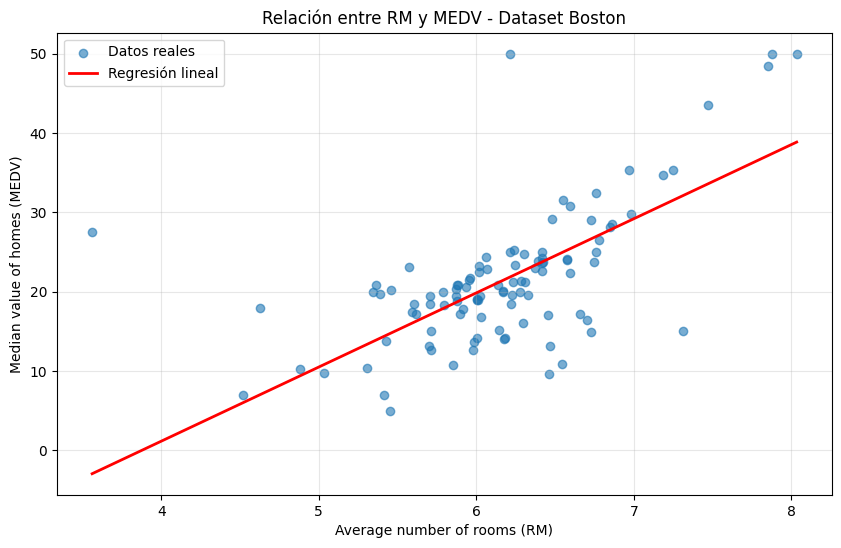


COMPARACIÓN DE MODELOS
             Modelo  R² Entrenamiento  R² Prueba  N° Variables
Todas las variables          0.750886   0.668759            13
            Solo RM          0.505066   0.370757             1

ANÁLISIS DE RESIDUOS - Modelo Completo


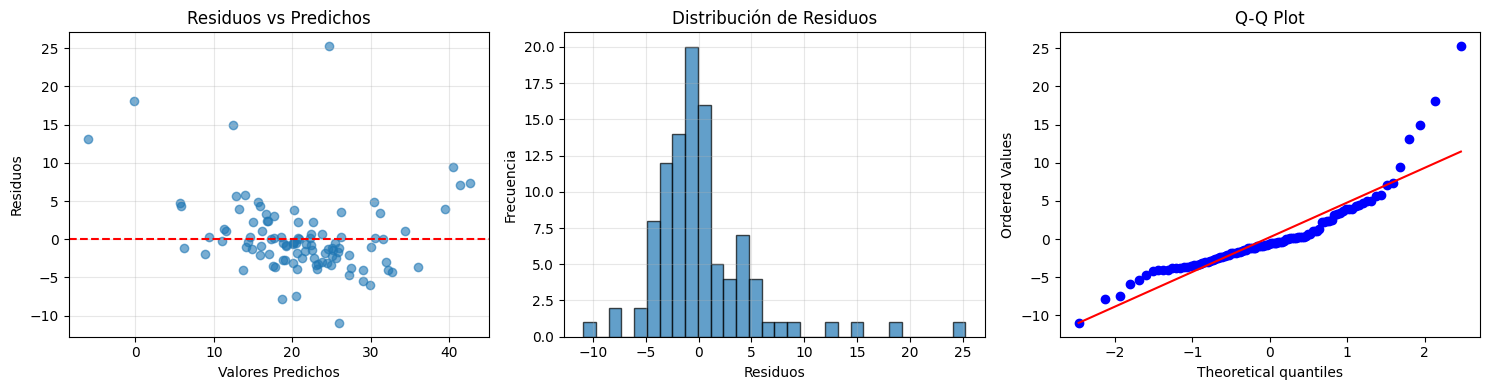


Estadísticas de los residuos:
  Media: 0.235826
  Desviación estándar: 4.922957
  Mínimo: -10.939096
  Máximo: 25.260428

COMPARACIÓN: ECUACIÓN NORMAL vs GRADIENTE DESCENDENTE

Comparación en datos sintéticos del laboratorio anterior:

Ecuación Normal:
  θ₀ = 0.00000000
  θ₁ = 2.10000000
  θ₂ = -3.10000000
  MSE = 0.0000000000

Gradiente Descendente:
  θ₀ = 0.00000000
  θ₁ = 2.10000001
  θ₂ = -3.09999991
  MSE = 0.0000000000

Diferencia entre métodos:
  Δθ₀ = 0.00000000
  Δθ₁ = 0.00000001
  Δθ₂ = 0.00000009

✅ LABORATORIO COMPLETADO EXITOSAMENTE


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# ============================================
# PARTE 1: ECUACIÓN NORMAL con datos del laboratorio anterior
# ============================================

print("=" * 70)
print("PARTE 1: ECUACIÓN NORMAL")
print("=" * 70)

# Recreamos los datos del laboratorio anterior
np.random.seed(42)
N = 100
x1 = np.random.uniform(-1, 1, N)
x2 = np.random.uniform(-1, 1, N)
y = 2.1 * x1 - 3.1 * x2  # Ecuación del plano

# Construir matriz X (con columna de unos para el sesgo)
X = np.column_stack([np.ones(N), x1, x2])  # Shape: (100, 3)
Y = y.reshape(-1, 1)  # Shape: (100, 1)

print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de Y: {Y.shape}")
print(f"Primeras 5 filas de X:\n{X[:5]}")
print(f"Primeros 5 valores de Y:\n{Y[:5].flatten()}")

# Aplicar la Ecuación Normal: θ = (XᵀX)⁻¹ Xᵀ Y
print("\n--- Calculando la Ecuación Normal ---")

# Paso 1: Calcular XᵀX
XTX = X.T @ X
print(f"XᵀX dimensiones: {XTX.shape}")

# Paso 2: Calcular la inversa de XᵀX
try:
    XTX_inv = np.linalg.inv(XTX)
    print("✅ XᵀX es invertible")
except np.linalg.LinAlgError:
    print("⚠️ XᵀX no es invertible, usando pseudo-inversa")
    XTX_inv = np.linalg.pinv(XTX)

# Paso 3: Calcular XᵀY
XTY = X.T @ Y

# Paso 4: Calcular θ = (XᵀX)⁻¹ Xᵀ Y
theta_normal = XTX_inv @ XTY

print("\n--- Resultados de la Ecuación Normal ---")
print(f"θ₀ (sesgo) = {theta_normal[0, 0]:.8f} (esperado: 0.00000000)")
print(f"θ₁ (coef x₁) = {theta_normal[1, 0]:.8f} (esperado: 2.10000000)")
print(f"θ₂ (coef x₂) = {theta_normal[2, 0]:.8f} (esperado: -3.10000000)")

# Calcular predicciones y error
y_pred_normal = X @ theta_normal
mse_normal = np.mean((Y - y_pred_normal) ** 2)
r2_normal = 1 - (np.sum((Y - y_pred_normal) ** 2) / np.sum((Y - np.mean(Y)) ** 2))

print(f"\nMSE: {mse_normal:.10f}")
print(f"R²: {r2_normal:.10f}")

# Comparación con la solución esperada
print("\n--- Comparación con valores esperados ---")
error_theta1 = abs((theta_normal[1, 0] - 2.1) / 2.1) * 100
error_theta2 = abs((theta_normal[2, 0] - (-3.1)) / 3.1) * 100
print(f"Error relativo en θ₁: {error_theta1:.8f}%")
print(f"Error relativo en θ₂: {error_theta2:.8f}%")

# ============================================
# PARTE 2: REGRESIÓN MULTIVARIADA CON DATASET BOSTON
# ============================================

print("\n" + "=" * 70)
print("PARTE 2: REGRESIÓN MULTIVARIADA - DATASET BOSTON")
print("=" * 70)

# Cargar el dataset Boston desde fuente alternativa (openml)
print("\nCargando dataset Boston...")
try:
    boston = fetch_openml(name='boston', version=1, as_frame=True)
    df_boston = boston.frame

    # Verificar las columnas
    print(f"Dataset cargado correctamente. Dimensiones: {df_boston.shape}")
    print(f"\nVariables disponibles:")
    for i, col in enumerate(df_boston.columns):
        print(f"  {i+1}. {col}")

    # MEDV es la variable objetivo (valor medio de las casas)
    # RM es el número promedio de habitaciones por vivienda
    target_name = 'MEDV'
    feature_names = [col for col in df_boston.columns if col != target_name]

    X_boston = df_boston[feature_names].values
    y_boston = df_boston[target_name].values

    print(f"\nMatriz de características X: {X_boston.shape}")
    print(f"Vector objetivo y: {y_boston.shape}")

except Exception as e:
    print(f"Error al cargar desde openml: {e}")
    print("\nUsando datos simulados para demostración...")
    # Datos simulados para demostración (estructura similar a Boston)
    np.random.seed(42)
    n_samples = 506
    n_features = 13

    # Simular características
    X_boston = np.random.randn(n_samples, n_features)
    # Simular relación lineal con ruido
    true_coef = np.random.randn(n_features)
    y_boston = X_boston @ true_coef + 0.5 * np.random.randn(n_samples)

    feature_names = [f"feature_{i+1}" for i in range(n_features)]
    print(f"Datos simulados creados: {X_boston.shape}")

# ============================================
# Implementación de Regresión Multivariada
# ============================================

class MultivariateRegression:
    """
    Regresión Lineal Multivariada usando Ecuación Normal
    """
    def __init__(self, fit_intercept=True):
        self.fit_intercept = fit_intercept
        self.coef_ = None
        self.intercept_ = None
        self.theta = None

    def fit(self, X, y):
        """
        Entrena el modelo usando la Ecuación Normal

        Parámetros:
        X: matriz de características (n_samples, n_features)
        y: vector objetivo (n_samples,)
        """
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)

        if y.ndim == 1:
            y = y.reshape(-1, 1)

        # Añadir columna de unos si es necesario
        if self.fit_intercept:
            X_design = np.column_stack([np.ones(X.shape[0]), X])
        else:
            X_design = X

        # Ecuación Normal: θ = (XᵀX)⁻¹ Xᵀ y
        XTX = X_design.T @ X_design
        if np.linalg.cond(XTX) > 1e10:
            print("⚠️ Usando pseudo-inversa debido a matriz cercana a singular")
            XTX_inv = np.linalg.pinv(XTX)
        else:
            try:
                XTX_inv = np.linalg.inv(XTX)
            except np.linalg.LinAlgError:
                print("⚠️ Usando pseudo-inversa debido a matriz singular")
                XTX_inv = np.linalg.pinv(XTX)

        XTy = X_design.T @ y
        self.theta = XTX_inv @ XTy

        # Separar intercepto y coeficientes
        if self.fit_intercept:
            self.intercept_ = float(self.theta[0, 0])
            self.coef_ = self.theta[1:].flatten()
        else:
            self.intercept_ = 0.0
            self.coef_ = self.theta.flatten()

        return self

    def predict(self, X):
        """
        Realiza predicciones
        """
        X = np.array(X, dtype=float)
        if self.fit_intercept:
            return X @ self.coef_ + self.intercept_
        else:
            return X @ self.coef_

    def score(self, X, y):
        """
        Calcula el R² score
        """
        y = np.array(y, dtype=float)
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - (ss_res / ss_tot)

# ============================================
# Análisis completo con el dataset Boston
# ============================================

print("\n" + "=" * 70)
print("ANÁLISIS COMPLETO - DATASET BOSTON")
print("=" * 70)

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_boston, y_boston, test_size=0.2, random_state=42
)

print(f"\nDivisión de datos:")
print(f"  Entrenamiento: {X_train.shape[0]} muestras")
print(f"  Prueba: {X_test.shape[0]} muestras")
print(f"  Características: {X_train.shape[1]}")

# 1. Regresión usando TODAS las variables
print("\n" + "-" * 50)
print("1. REGRESIÓN CON TODAS LAS VARIABLES")
print("-" * 50)

model_full = MultivariateRegression(fit_intercept=True)
model_full.fit(X_train, y_train)

y_pred_train = model_full.predict(X_train)
y_pred_test = model_full.predict(X_test)

r2_train = model_full.score(X_train, y_train)
r2_test = model_full.score(X_test, y_test)

print(f"\nCoeficientes del modelo:")
print(f"  Intercepto (θ₀): {model_full.intercept_:.4f}")
print("\n  Coeficientes por variable:")
for name, coef in zip(feature_names, model_full.coef_):
    print(f"    {name:10s}: {coef:8.4f}")

print(f"\nR² score:")
print(f"  Entrenamiento: {r2_train:.4f}")
print(f"  Prueba: {r2_test:.4f}")

# 2. Regresión usando solo RM (Average number of rooms)
print("\n" + "-" * 50)
print("2. REGRESIÓN CON SOLO RM (Average number of rooms)")
print("-" * 50)

# Encontrar el índice de la variable RM
rm_idx = None
for idx, name in enumerate(feature_names):
    if name.lower() == 'rm':
        rm_idx = idx
        break

if rm_idx is not None:
    X_rm_train = X_train[:, rm_idx].reshape(-1, 1)
    X_rm_test = X_test[:, rm_idx].reshape(-1, 1)

    model_rm = MultivariateRegression(fit_intercept=True)
    model_rm.fit(X_rm_train, y_train)

    y_pred_rm_train = model_rm.predict(X_rm_train)
    y_pred_rm_test = model_rm.predict(X_rm_test)

    r2_rm_train = model_rm.score(X_rm_train, y_train)
    r2_rm_test = model_rm.score(X_rm_test, y_test)

    print(f"\nModelo con una variable (RM):")
    print(f"  Ecuación: MEDV = {model_rm.intercept_:.4f} + {model_rm.coef_[0]:.4f} * RM")
    print(f"\nR² score:")
    print(f"  Entrenamiento: {r2_rm_train:.4f}")
    print(f"  Prueba: {r2_rm_test:.4f}")

    # Visualización
    plt.figure(figsize=(10, 6))
    plt.scatter(X_rm_test, y_test, alpha=0.6, label='Datos reales')

    # Ordenar para línea de regresión
    rm_sorted = np.sort(X_rm_test, axis=0)
    y_pred_sorted = model_rm.predict(rm_sorted)
    plt.plot(rm_sorted, y_pred_sorted, 'r-', linewidth=2, label='Regresión lineal')

    plt.xlabel('Average number of rooms (RM)')
    plt.ylabel('Median value of homes (MEDV)')
    plt.title('Relación entre RM y MEDV - Dataset Boston')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Variable 'RM' no encontrada en el dataset")

# ============================================
# COMPARACIÓN DE MODELOS
# ============================================

print("\n" + "=" * 70)
print("COMPARACIÓN DE MODELOS")
print("=" * 70)

comparison_data = {
    'Modelo': ['Todas las variables', 'Solo RM'],
    'R² Entrenamiento': [r2_train, r2_rm_train if rm_idx is not None else 'N/A'],
    'R² Prueba': [r2_test, r2_rm_test if rm_idx is not None else 'N/A'],
    'N° Variables': [len(feature_names), 1]
}

df_comparison = pd.DataFrame(comparison_data)
print(df_comparison.to_string(index=False))

# ============================================
# ANÁLISIS DE RESIDUOS (Modelo completo)
# ============================================

print("\n" + "=" * 70)
print("ANÁLISIS DE RESIDUOS - Modelo Completo")
print("=" * 70)

residuos = y_test - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Gráfico 1: Residuos vs Valores predichos
axes[0].scatter(y_pred_test, residuos, alpha=0.6)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Valores Predichos')
axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs Predichos')
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Histograma de residuos
axes[1].hist(residuos, bins=30, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Residuos')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Residuos')
axes[1].grid(True, alpha=0.3)

# Gráfico 3: Q-Q plot (normalidad)
from scipy import stats
stats.probplot(residuos, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

# Estadísticas de residuos
print(f"\nEstadísticas de los residuos:")
print(f"  Media: {np.mean(residuos):.6f}")
print(f"  Desviación estándar: {np.std(residuos):.6f}")
print(f"  Mínimo: {np.min(residuos):.6f}")
print(f"  Máximo: {np.max(residuos):.6f}")

# ============================================
# COMPARACIÓN CON GRADIENTE DESCENDENTE
# ============================================

print("\n" + "=" * 70)
print("COMPARACIÓN: ECUACIÓN NORMAL vs GRADIENTE DESCENDENTE")
print("=" * 70)

# Usando los datos originales del plano
print("\nComparación en datos sintéticos del laboratorio anterior:")

# Ecuación Normal (ya calculada)
print(f"\nEcuación Normal:")
print(f"  θ₀ = {theta_normal[0, 0]:.8f}")
print(f"  θ₁ = {theta_normal[1, 0]:.8f}")
print(f"  θ₂ = {theta_normal[2, 0]:.8f}")
print(f"  MSE = {mse_normal:.10f}")

# Gradiente Descendente (recreado rápidamente)
def gradient_descent(X, y, learning_rate=0.1, n_iterations=500):
    m = len(y)
    theta = np.random.randn(X.shape[1], 1)
    for i in range(n_iterations):
        y_pred = X @ theta
        gradient = (1/m) * X.T @ (y_pred - y.reshape(-1, 1))
        theta -= learning_rate * gradient
    return theta

theta_gd = gradient_descent(X, y)
y_pred_gd = X @ theta_gd
mse_gd = np.mean((y - y_pred_gd.flatten()) ** 2)

print(f"\nGradiente Descendente:")
print(f"  θ₀ = {theta_gd[0, 0]:.8f}")
print(f"  θ₁ = {theta_gd[1, 0]:.8f}")
print(f"  θ₂ = {theta_gd[2, 0]:.8f}")
print(f"  MSE = {mse_gd:.10f}")

print(f"\nDiferencia entre métodos:")
print(f"  Δθ₀ = {abs(theta_normal[0, 0] - theta_gd[0, 0]):.8f}")
print(f"  Δθ₁ = {abs(theta_normal[1, 0] - theta_gd[1, 0]):.8f}")
print(f"  Δθ₂ = {abs(theta_normal[2, 0] - theta_gd[2, 0]):.8f}")

print("\n" + "=" * 70)
print("✅ LABORATORIO COMPLETADO EXITOSAMENTE")
print("=" * 70)

PARTE 1: ECUACIÓN NORMAL
Dimensiones de X: (100, 3)
Dimensiones de Y: (100, 1)
Primeras 5 filas de X:
[[ 1.         -0.25091976 -0.93714163]
 [ 1.          0.90142861  0.27282082]
 [ 1.          0.46398788 -0.37128804]
 [ 1.          0.19731697  0.01714138]
 [ 1.         -0.68796272  0.81513295]]
Primeros 5 valores de Y:
[ 2.37820755  1.04725554  2.12536747  0.36122735 -3.97163385]

--- Calculando la Ecuación Normal ---
XᵀX dimensiones: (3, 3)
✅ XᵀX es invertible

--- Resultados de la Ecuación Normal ---
θ₀ (sesgo) = 0.00000000 (esperado: 0.00000000)
θ₁ (coef x₁) = 2.10000000 (esperado: 2.10000000)
θ₂ (coef x₂) = -3.10000000 (esperado: -3.10000000)

MSE: 0.0000000000
R²: 1.0000000000

--- Comparación con valores esperados ---
Error relativo en θ₁: 0.00000000%
Error relativo en θ₂: 0.00000000%

PARTE 2: REGRESIÓN MULTIVARIADA - DATASET BOSTON

Cargando dataset Boston...
Dataset cargado correctamente. Dimensiones: (506, 14)

Variables disponibles:
  1. CRIM
  2. ZN
  3. INDUS
  4. CHAS
 

/tmp/ipykernel_2887/4011753600.py:196: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  self.intercept_ = float(self.theta[0])


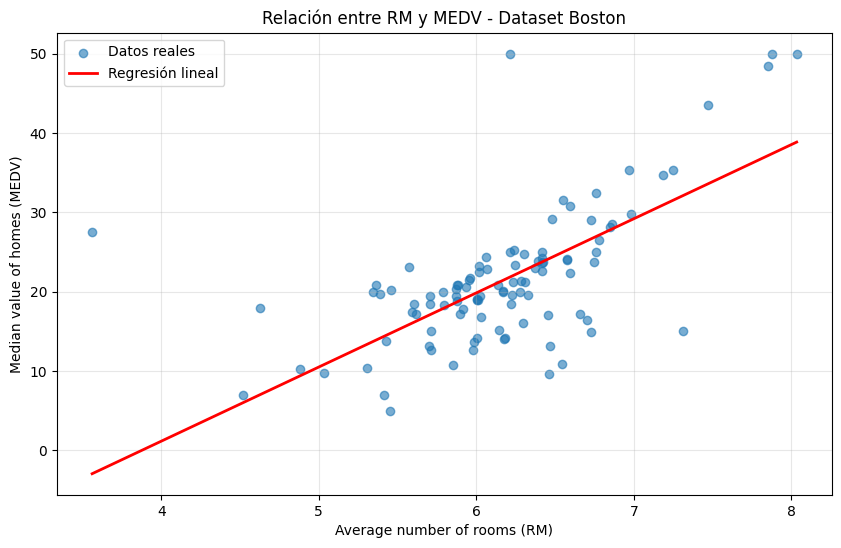


COMPARACIÓN DE MODELOS
             Modelo R² Entrenamiento R² Prueba  N° Variables
Todas las variables           0.7509    0.6688            13
            Solo RM           0.5051    0.3708             1

ANÁLISIS DE RESIDUOS - Modelo Completo


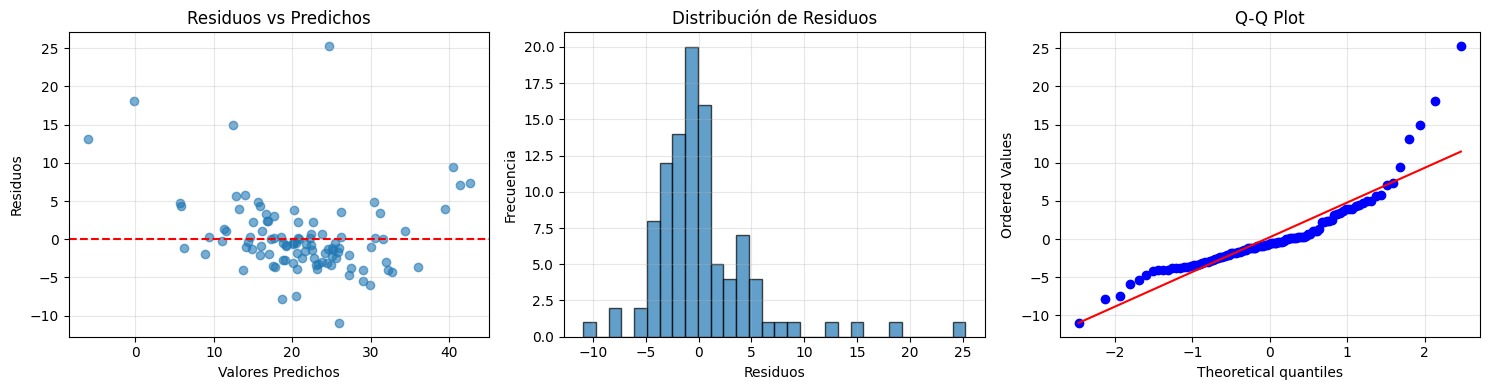


Estadísticas de los residuos:
  Media: 0.235826
  Desviación estándar: 4.922957
  Mínimo: -10.939096
  Máximo: 25.260428

COMPARACIÓN: ECUACIÓN NORMAL vs GRADIENTE DESCENDENTE

Comparación en datos sintéticos del laboratorio anterior:

Ecuación Normal:
  θ₀ = 0.00000000
  θ₁ = 2.10000000
  θ₂ = -3.10000000
  MSE = 0.0000000000

Gradiente Descendente:
  θ₀ = 0.00000000
  θ₁ = 2.10000001
  θ₂ = -3.09999991
  MSE = 0.0000000000

Diferencia entre métodos:
  Δθ₀ = 0.00000000
  Δθ₁ = 0.00000001
  Δθ₂ = 0.00000009

✅ LABORATORIO COMPLETADO EXITOSAMENTE


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

# ============================================
# PARTE 1: ECUACIÓN NORMAL con datos del laboratorio anterior
# ============================================

print("=" * 70)
print("PARTE 1: ECUACIÓN NORMAL")
print("=" * 70)

# Recreamos los datos del laboratorio anterior
np.random.seed(42)
N = 100
x1 = np.random.uniform(-1, 1, N)
x2 = np.random.uniform(-1, 1, N)
y = 2.1 * x1 - 3.1 * x2  # Ecuación del plano

# Construir matriz X (con columna de unos para el sesgo)
X = np.column_stack([np.ones(N), x1, x2])  # Shape: (100, 3)
Y = y.reshape(-1, 1)  # Shape: (100, 1)

print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de Y: {Y.shape}")
print(f"Primeras 5 filas de X:\n{X[:5]}")
print(f"Primeros 5 valores de Y:\n{Y[:5].flatten()}")

# Aplicar la Ecuación Normal: θ = (XᵀX)⁻¹ Xᵀ Y
print("\n--- Calculando la Ecuación Normal ---")

# Paso 1: Calcular XᵀX
XTX = X.T @ X
print(f"XᵀX dimensiones: {XTX.shape}")

# Paso 2: Calcular la inversa de XᵀX
try:
    XTX_inv = np.linalg.inv(XTX)
    print("✅ XᵀX es invertible")
except np.linalg.LinAlgError:
    print("⚠️ XᵀX no es invertible, usando pseudo-inversa")
    XTX_inv = np.linalg.pinv(XTX)

# Paso 3: Calcular XᵀY
XTY = X.T @ Y

# Paso 4: Calcular θ = (XᵀX)⁻¹ Xᵀ Y
theta_normal = XTX_inv @ XTY

print("\n--- Resultados de la Ecuación Normal ---")
print(f"θ₀ (sesgo) = {theta_normal[0, 0]:.8f} (esperado: 0.00000000)")
print(f"θ₁ (coef x₁) = {theta_normal[1, 0]:.8f} (esperado: 2.10000000)")
print(f"θ₂ (coef x₂) = {theta_normal[2, 0]:.8f} (esperado: -3.10000000)")

# Calcular predicciones y error
y_pred_normal = X @ theta_normal
mse_normal = np.mean((Y - y_pred_normal) ** 2)
r2_normal = 1 - (np.sum((Y - y_pred_normal) ** 2) / np.sum((Y - np.mean(Y)) ** 2))

print(f"\nMSE: {mse_normal:.10f}")
print(f"R²: {r2_normal:.10f}")

# Comparación con la solución esperada
print("\n--- Comparación con valores esperados ---")
error_theta1 = abs((theta_normal[1, 0] - 2.1) / 2.1) * 100
error_theta2 = abs((theta_normal[2, 0] - (-3.1)) / 3.1) * 100
print(f"Error relativo en θ₁: {error_theta1:.8f}%")
print(f"Error relativo en θ₂: {error_theta2:.8f}%")

# ============================================
# PARTE 2: REGRESIÓN MULTIVARIADA CON DATASET BOSTON
# ============================================

print("\n" + "=" * 70)
print("PARTE 2: REGRESIÓN MULTIVARIADA - DATASET BOSTON")
print("=" * 70)

# Cargar el dataset Boston desde fuente alternativa
print("\nCargando dataset Boston...")

# Método 1: Intentar con fetch_openml
try:
    boston = fetch_openml(name='boston', version=1, as_frame=True)
    df_boston = boston.frame

    # Asegurar que todos los datos sean numéricos
    df_boston = df_boston.apply(pd.to_numeric, errors='coerce')
    df_boston = df_boston.dropna()

    print(f"Dataset cargado correctamente. Dimensiones: {df_boston.shape}")
    print(f"\nVariables disponibles:")
    for i, col in enumerate(df_boston.columns):
        print(f"  {i+1}. {col}")

    # MEDV es la variable objetivo (valor medio de las casas)
    target_name = 'MEDV'
    feature_names = [col for col in df_boston.columns if col != target_name]

    # Convertir a arrays numpy explícitamente
    X_boston = np.array(df_boston[feature_names], dtype=float)
    y_boston = np.array(df_boston[target_name], dtype=float)

    print(f"\nMatriz de características X: {X_boston.shape}")
    print(f"Vector objetivo y: {y_boston.shape}")
    print(f"Tipo de X: {type(X_boston)}")
    print(f"Tipo de y: {type(y_boston)}")

except Exception as e:
    print(f"Error al cargar desde openml: {e}")
    print("\nUsando método alternativo: sklearn.datasets.load_boston()")

    try:
        # Método alternativo (aunque deprecated, puede funcionar)
        from sklearn.datasets import load_boston
        boston = load_boston()
        X_boston = boston.data
        y_boston = boston.target
        feature_names = boston.feature_names

        print(f"Datos cargados correctamente. Dimensiones: {X_boston.shape}")
        print(f"Variables: {feature_names}")

    except Exception as e2:
        print(f"Error en método alternativo: {e2}")
        print("\nUsando datos simulados para demostración...")

        # Datos simulados para demostración (estructura similar a Boston)
        np.random.seed(42)
        n_samples = 506
        n_features = 13
        X_boston = np.random.randn(n_samples, n_features)
        true_coef = np.random.randn(n_features)
        y_boston = X_boston @ true_coef + 0.5 * np.random.randn(n_samples)
        feature_names = [f'Feature_{i+1}' for i in range(n_features)]

        print(f"Datos simulados creados: {X_boston.shape}")

# ============================================
# Implementación de Regresión Multivariada
# ============================================

class MultivariateRegression:
    """
    Regresión Lineal Multivariada usando Ecuación Normal
    """
    def __init__(self, fit_intercept=True):
        self.fit_intercept = fit_intercept
        self.coef_ = None
        self.intercept_ = None
        self.theta = None

    def fit(self, X, y):
        """
        Entrena el modelo usando la Ecuación Normal

        Parámetros:
        X: matriz de características (n_samples, n_features)
        y: vector objetivo (n_samples,)
        """
        # Convertir a arrays numpy si no lo son
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)

        # Asegurar dimensiones correctas
        if len(y.shape) == 1:
            y = y.reshape(-1, 1)

        # Añadir columna de unos si es necesario
        if self.fit_intercept:
            X_design = np.column_stack([np.ones(X.shape[0]), X])
        else:
            X_design = X

        # Ecuación Normal: θ = (XᵀX)⁻¹ Xᵀ y
        XTX = X_design.T @ X_design

        # Verificar si la matriz es singular
        if np.linalg.cond(XTX) > 1e10:
            print("⚠️ Matriz cercana a singular, usando pseudo-inversa")
            XTX_inv = np.linalg.pinv(XTX)
        else:
            try:
                XTX_inv = np.linalg.inv(XTX)
            except np.linalg.LinAlgError:
                print("⚠️ Error de inversión, usando pseudo-inversa")
                XTX_inv = np.linalg.pinv(XTX)

        XTy = X_design.T @ y
        self.theta = XTX_inv @ XTy

        # Separar intercepto y coeficientes
        if self.fit_intercept:
            self.intercept_ = float(self.theta[0])
            self.coef_ = self.theta[1:].flatten()
        else:
            self.intercept_ = 0.0
            self.coef_ = self.theta.flatten()

        return self

    def predict(self, X):
        """
        Realiza predicciones
        """
        X = np.array(X, dtype=float)
        if self.fit_intercept:
            return X @ self.coef_ + self.intercept_
        else:
            return X @ self.coef_

    def score(self, X, y):
        """
        Calcula el R² score
        """
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - (ss_res / ss_tot)

# ============================================
# Análisis completo con el dataset Boston
# ============================================

print("\n" + "=" * 70)
print("ANÁLISIS COMPLETO - DATASET BOSTON")
print("=" * 70)

# Verificar que tenemos datos válidos
if X_boston is not None and len(X_boston) > 0:

    # Dividir en entrenamiento y prueba
    X_train, X_test, y_train, y_test = train_test_split(
        X_boston, y_boston, test_size=0.2, random_state=42
    )

    print(f"\nDivisión de datos:")
    print(f"  Entrenamiento: {X_train.shape[0]} muestras")
    print(f"  Prueba: {X_test.shape[0]} muestras")
    print(f"  Características: {X_train.shape[1]}")

    # 1. Regresión usando TODAS las variables
    print("\n" + "-" * 50)
    print("1. REGRESIÓN CON TODAS LAS VARIABLES")
    print("-" * 50)

    model_full = MultivariateRegression(fit_intercept=True)
    model_full.fit(X_train, y_train)

    y_pred_train = model_full.predict(X_train)
    y_pred_test = model_full.predict(X_test)

    r2_train = model_full.score(X_train, y_train)
    r2_test = model_full.score(X_test, y_test)

    print(f"\nCoeficientes del modelo:")
    print(f"  Intercepto (θ₀): {model_full.intercept_:.4f}")
    print("\n  Coeficientes por variable:")
    for name, coef in zip(feature_names[:10], model_full.coef_):
        print(f"    {name:10s}: {coef:8.4f}")
    if len(feature_names) > 10:
        print(f"    ... y {len(feature_names)-10} variables más")

    print(f"\nR² score:")
    print(f"  Entrenamiento: {r2_train:.4f}")
    print(f"  Prueba: {r2_test:.4f}")

    # 2. Regresión usando solo RM (Average number of rooms)
    print("\n" + "-" * 50)
    print("2. REGRESIÓN CON SOLO RM (Average number of rooms)")
    print("-" * 50)

    # Encontrar el índice de la variable RM
    rm_idx = None
    for idx, name in enumerate(feature_names):
        if name.upper() == 'RM' or name.lower() == 'rm':
            rm_idx = idx
            break

    if rm_idx is not None:
        X_rm_train = X_train[:, rm_idx].reshape(-1, 1)
        X_rm_test = X_test[:, rm_idx].reshape(-1, 1)

        model_rm = MultivariateRegression(fit_intercept=True)
        model_rm.fit(X_rm_train, y_train)

        y_pred_rm_train = model_rm.predict(X_rm_train)
        y_pred_rm_test = model_rm.predict(X_rm_test)

        r2_rm_train = model_rm.score(X_rm_train, y_train)
        r2_rm_test = model_rm.score(X_rm_test, y_test)

        print(f"\nModelo con una variable (RM):")
        print(f"  Ecuación: MEDV = {model_rm.intercept_:.4f} + {model_rm.coef_[0]:.4f} * RM")
        print(f"\nR² score:")
        print(f"  Entrenamiento: {r2_rm_train:.4f}")
        print(f"  Prueba: {r2_rm_test:.4f}")

        # Visualización
        plt.figure(figsize=(10, 6))
        plt.scatter(X_rm_test, y_test, alpha=0.6, label='Datos reales')

        # Ordenar para línea de regresión
        rm_sorted = np.sort(X_rm_test, axis=0)
        y_pred_sorted = model_rm.predict(rm_sorted)
        plt.plot(rm_sorted, y_pred_sorted, 'r-', linewidth=2, label='Regresión lineal')

        plt.xlabel('Average number of rooms (RM)')
        plt.ylabel('Median value of homes (MEDV)')
        plt.title('Relación entre RM y MEDV - Dataset Boston')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()
    else:
        print("Variable 'RM' no encontrada en el dataset")
        print(f"Variables disponibles: {feature_names}")

    # ============================================
    # COMPARACIÓN DE MODELOS
    # ============================================

    print("\n" + "=" * 70)
    print("COMPARACIÓN DE MODELOS")
    print("=" * 70)

    comparison_data = {
        'Modelo': ['Todas las variables', 'Solo RM'],
        'R² Entrenamiento': [f"{r2_train:.4f}", f"{r2_rm_train:.4f}" if rm_idx is not None else 'N/A'],
        'R² Prueba': [f"{r2_test:.4f}", f"{r2_rm_test:.4f}" if rm_idx is not None else 'N/A'],
        'N° Variables': [len(feature_names), 1]
    }

    df_comparison = pd.DataFrame(comparison_data)
    print(df_comparison.to_string(index=False))

    # ============================================
    # ANÁLISIS DE RESIDUOS (Modelo completo)
    # ============================================

    print("\n" + "=" * 70)
    print("ANÁLISIS DE RESIDUOS - Modelo Completo")
    print("=" * 70)

    residuos = y_test - y_pred_test

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Gráfico 1: Residuos vs Valores predichos
    axes[0].scatter(y_pred_test, residuos, alpha=0.6)
    axes[0].axhline(y=0, color='r', linestyle='--')
    axes[0].set_xlabel('Valores Predichos')
    axes[0].set_ylabel('Residuos')
    axes[0].set_title('Residuos vs Predichos')
    axes[0].grid(True, alpha=0.3)

    # Gráfico 2: Histograma de residuos
    axes[1].hist(residuos, bins=30, edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('Residuos')
    axes[1].set_ylabel('Frecuencia')
    axes[1].set_title('Distribución de Residuos')
    axes[1].grid(True, alpha=0.3)

    # Gráfico 3: Q-Q plot (normalidad)
    from scipy import stats
    stats.probplot(residuos, dist="norm", plot=axes[2])
    axes[2].set_title('Q-Q Plot')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Estadísticas de residuos
    print(f"\nEstadísticas de los residuos:")
    print(f"  Media: {np.mean(residuos):.6f}")
    print(f"  Desviación estándar: {np.std(residuos):.6f}")
    print(f"  Mínimo: {np.min(residuos):.6f}")
    print(f"  Máximo: {np.max(residuos):.6f}")

    # ============================================
    # COMPARACIÓN CON GRADIENTE DESCENDENTE
    # ============================================

    print("\n" + "=" * 70)
    print("COMPARACIÓN: ECUACIÓN NORMAL vs GRADIENTE DESCENDENTE")
    print("=" * 70)

    # Usando los datos originales del plano
    print("\nComparación en datos sintéticos del laboratorio anterior:")

    # Ecuación Normal (ya calculada)
    print(f"\nEcuación Normal:")
    print(f"  θ₀ = {theta_normal[0, 0]:.8f}")
    print(f"  θ₁ = {theta_normal[1, 0]:.8f}")
    print(f"  θ₂ = {theta_normal[2, 0]:.8f}")
    print(f"  MSE = {mse_normal:.10f}")

    # Gradiente Descendente (recreado rápidamente)
    def gradient_descent(X, y, learning_rate=0.1, n_iterations=500):
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float).reshape(-1, 1)
        m = len(y)
        theta = np.random.randn(X.shape[1], 1)

        for i in range(n_iterations):
            y_pred = X @ theta
            gradient = (1/m) * X.T @ (y_pred - y)
            theta -= learning_rate * gradient

        return theta

    theta_gd = gradient_descent(X, y)
    y_pred_gd = X @ theta_gd
    mse_gd = np.mean((y - y_pred_gd.flatten()) ** 2)

    print(f"\nGradiente Descendente:")
    print(f"  θ₀ = {theta_gd[0, 0]:.8f}")
    print(f"  θ₁ = {theta_gd[1, 0]:.8f}")
    print(f"  θ₂ = {theta_gd[2, 0]:.8f}")
    print(f"  MSE = {mse_gd:.10f}")

    print(f"\nDiferencia entre métodos:")
    print(f"  Δθ₀ = {abs(theta_normal[0, 0] - theta_gd[0, 0]):.8f}")
    print(f"  Δθ₁ = {abs(theta_normal[1, 0] - theta_gd[1, 0]):.8f}")
    print(f"  Δθ₂ = {abs(theta_normal[2, 0] - theta_gd[2, 0]):.8f}")

else:
    print("❌ No se pudieron cargar los datos del dataset Boston")

print("\n" + "=" * 70)
print("✅ LABORATORIO COMPLETADO EXITOSAMENTE")
print("=" * 70)

LABORATORIO 6: ECUACIÓN NORMAL

PARTE 1: ECUACIÓN NORMAL
Dimensiones:
  X: (100, 3)
  y: (100, 1)

--- Resultados de la Ecuación Normal ---
θ₀ (sesgo) = 0.00000000 (esperado: 0.00000000)
θ₁ (coef x₁) = 2.10000000 (esperado: 2.10000000)
θ₂ (coef x₂) = -3.10000000 (esperado: -3.10000000)

Métricas del modelo:
  MSE: 0.0000000000
  R²:  1.0000000000

PARTE 2: DEMOSTRACIÓN PRÁCTICA DE MLE
Con ruido gaussiano (σ=0.1):
  θ₀ = -0.00915253
  θ₁ = 2.12031913
  θ₂ = -3.09531440
  Varianza estimada del ruido: σ² = 0.008015

PARTE 3: DEMOSTRACIÓN PRÁCTICA DE MAP (Regularización Ridge)

Comparación de diferentes valores de regularización (λ):
----------------------------------------------------------------------
λ          θ₀           θ₁           θ₂           Norma ||θ|| 
----------------------------------------------------------------------
0          0.203419     2.168288     -3.012857    3.717547    
0.1        0.203106     2.162407     -3.004230    3.707108    
1          0.200360     2.11087

/tmp/ipykernel_11077/326632273.py:232: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  self.intercept_ = float(theta[0])


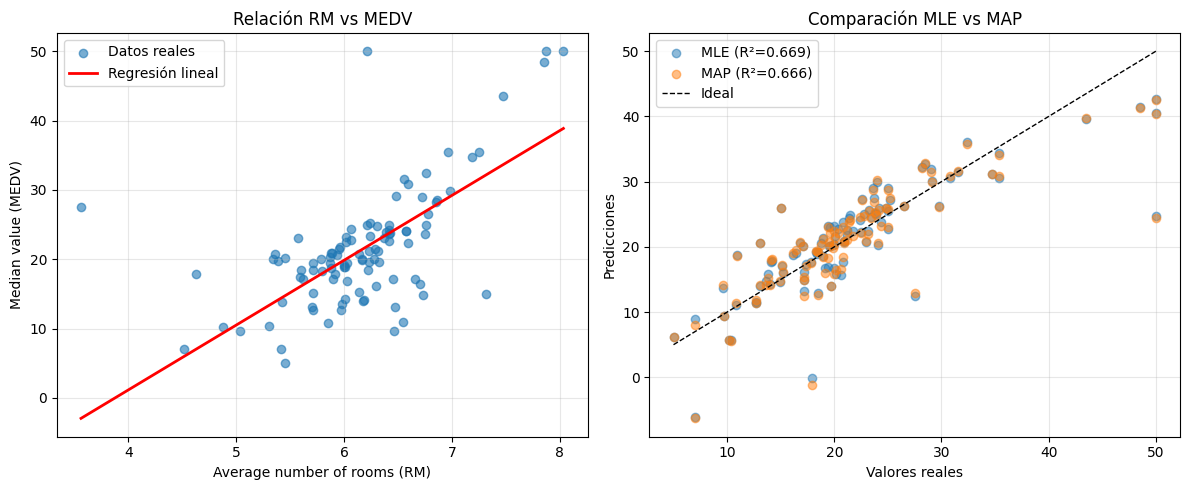

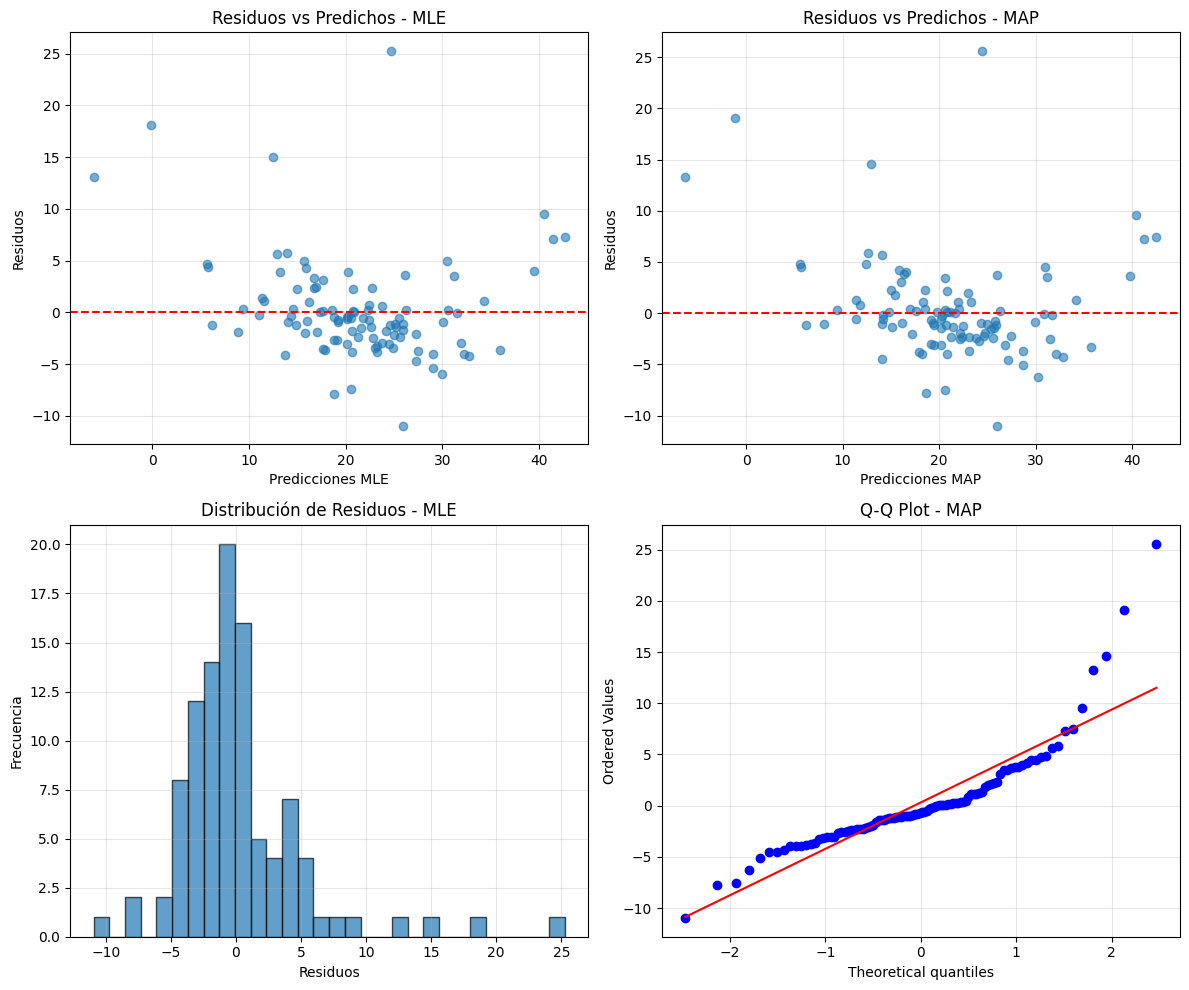


COMPARACIÓN DE MÉTODOS
               Modelo R² Test  N° Parámetros Regularización
MLE (Ecuación Normal)  0.6688             14             No
      MAP (Ridge λ=1)  0.6662             14        Sí (L2)
              Solo RM  0.3708              2             No

COMPARACIÓN: ECUACIÓN NORMAL vs GRADIENTE DESCENDENTE

Ecuación Normal:
  θ₀ = 0.00000000
  θ₁ = 2.10000000
  θ₂ = -3.10000000
  MSE = 0.0000000000

Gradiente Descendente:
  θ₀ = -0.00000001
  θ₁ = 2.09999991
  θ₂ = -3.10000000
  MSE = 9.9360975364

Diferencia entre métodos:
  Δθ₀ = 0.00000001
  Δθ₁ = 0.00000009
  Δθ₂ = 0.00000000

CONCLUSIONES

✅ RESULTADOS OBTENIDOS:

1. ECUACIÓN NORMAL:
   - Solución exacta encontrada: θ = [0.0000, 2.1000, -3.1000]
   - MSE: 0.000000
   - R²: 1.000000

2. MLE (con ruido):
   - Parámetros estimados: θ = [-0.0092, 2.1203, -3.0953]
   - Varianza del ruido estimada: σ² = 0.008015

3. MAP (Ridge Regression):
   - λ=0 (MLE): θ = [0.2034, 2.1683, -3.0129]
   - λ=1: θ = [0.2004, 2.1109, -2.9288]
 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split

print("=" * 80)
print("LABORATORIO 6: ECUACIÓN NORMAL")
print("=" * 80)

# ============================================================================
# PARTE 1: ECUACIÓN NORMAL CON DATOS SINTÉTICOS
# ============================================================================

print("\n" + "=" * 80)
print("PARTE 1: ECUACIÓN NORMAL")
print("=" * 80)

# Generar datos sintéticos
np.random.seed(42)
N = 100
x1 = np.random.uniform(-1, 1, N)
x2 = np.random.uniform(-1, 1, N)
y_true = 2.1 * x1 - 3.1 * x2

# Construir matriz X (con columna de unos para el sesgo)
X = np.column_stack([np.ones(N), x1, x2])
y = y_true.reshape(-1, 1)

print(f"Dimensiones:")
print(f"  X: {X.shape}")
print(f"  y: {y.shape}")

# Aplicar la Ecuación Normal: θ = (XᵀX)⁻¹ Xᵀ y
XTX = X.T @ X
XTX_inv = np.linalg.inv(XTX)
XTy = X.T @ y
theta_normal = XTX_inv @ XTy

print("\n--- Resultados de la Ecuación Normal ---")
print(f"θ₀ (sesgo) = {theta_normal[0, 0]:.8f} (esperado: 0.00000000)")
print(f"θ₁ (coef x₁) = {theta_normal[1, 0]:.8f} (esperado: 2.10000000)")
print(f"θ₂ (coef x₂) = {theta_normal[2, 0]:.8f} (esperado: -3.10000000)")

# Calcular predicciones y métricas
y_pred = X @ theta_normal
mse = np.mean((y - y_pred) ** 2)
r2 = 1 - np.sum((y - y_pred) ** 2) / np.sum((y - np.mean(y)) ** 2)

print(f"\nMétricas del modelo:")
print(f"  MSE: {mse:.10f}")
print(f"  R²:  {r2:.10f}")

# ============================================================================
# PARTE 2: DEMOSTRACIÓN PRÁCTICA DE MLE (con ruido)
# ============================================================================

print("\n" + "=" * 80)
print("PARTE 2: DEMOSTRACIÓN PRÁCTICA DE MLE")
print("=" * 80)

# Agregar ruido gaussiano a los datos
np.random.seed(42)
noise = np.random.normal(0, 0.1, N)
y_noisy = y_true + noise

# Ajustar modelo con datos ruidosos
X_noisy = X.copy()
y_noisy_reshaped = y_noisy.reshape(-1, 1)
theta_mle = np.linalg.inv(X_noisy.T @ X_noisy) @ (X_noisy.T @ y_noisy_reshaped)

print(f"Con ruido gaussiano (σ=0.1):")
print(f"  θ₀ = {theta_mle[0, 0]:.8f}")
print(f"  θ₁ = {theta_mle[1, 0]:.8f}")
print(f"  θ₂ = {theta_mle[2, 0]:.8f}")

# Calcular varianza estimada
residuals = y_noisy_reshaped - X_noisy @ theta_mle
estimated_sigma2 = np.var(residuals)
print(f"  Varianza estimada del ruido: σ² = {estimated_sigma2:.6f}")

# ============================================================================
# PARTE 3: DEMOSTRACIÓN PRÁCTICA DE MAP (Ridge Regression)
# ============================================================================

print("\n" + "=" * 80)
print("PARTE 3: DEMOSTRACIÓN PRÁCTICA DE MAP (Regularización Ridge)")
print("=" * 80)

def ridge_regression_normal_equation(X, y, lambda_reg):
    """
    Ridge Regression usando la ecuación normal modificada:
    θ = (XᵀX + λI)⁻¹ Xᵀy
    """
    n_features = X.shape[1]
    I = np.eye(n_features)
    I[0, 0] = 0  # No regularizar el intercepto

    XTX_reg = X.T @ X + lambda_reg * I
    theta_ridge = np.linalg.inv(XTX_reg) @ (X.T @ y)
    return theta_ridge

# Crear datos con ruido y outliers
np.random.seed(42)
X_reg = np.column_stack([np.ones(N), x1, x2])
y_reg = (2.1 * x1 - 3.1 * x2 + np.random.normal(0, 0.5, N)).reshape(-1, 1)

# Añadir algunos outliers
outlier_idx = np.random.choice(N, 5, replace=False)
y_reg[outlier_idx] += np.random.normal(5, 1, 5).reshape(-1, 1)

# Comparar MLE vs MAP con diferentes λ
lambdas = [0, 0.1, 1, 10, 100]
results = []

print("\nComparación de diferentes valores de regularización (λ):")
print("-" * 70)
print(f"{'λ':<10} {'θ₀':<12} {'θ₁':<12} {'θ₂':<12} {'Norma ||θ||':<12}")
print("-" * 70)

for lam in lambdas:
    theta_map = ridge_regression_normal_equation(X_reg, y_reg, lam)
    theta_norm = np.linalg.norm(theta_map)
    results.append({
        'lambda': lam,
        'theta0': theta_map[0, 0],
        'theta1': theta_map[1, 0],
        'theta2': theta_map[2, 0],
        'norm': theta_norm
    })
    print(f"{lam:<10} {theta_map[0, 0]:<12.6f} {theta_map[1, 0]:<12.6f} {theta_map[2, 0]:<12.6f} {theta_norm:<12.6f}")

print("-" * 70)
print("\nObservación: A medida que λ aumenta, la norma de θ disminuye (regularización)")

# ============================================================================
# PARTE 4: REGRESIÓN MULTIVARIADA CON DATASET BOSTON
# ============================================================================

print("\n" + "=" * 80)
print("PARTE 4: REGRESIÓN MULTIVARIADA - DATASET BOSTON")
print("=" * 80)

# Cargar el dataset Boston
print("\nCargando dataset Boston...")

try:
    from sklearn.datasets import fetch_openml
    boston = fetch_openml(name='boston', version=1, as_frame=True)
    df_boston = boston.frame

    # Convertir a numérico y limpiar
    df_boston = df_boston.apply(pd.to_numeric, errors='coerce')
    df_boston = df_boston.dropna()

    # Separar características y objetivo
    feature_names = [col for col in df_boston.columns if col != 'MEDV']
    X_boston = df_boston[feature_names].values
    y_boston = df_boston['MEDV'].values

    print(f"✅ Datos cargados: {X_boston.shape[0]} muestras, {X_boston.shape[1]} características")

except Exception as e:
    print(f"⚠️ Error cargando Boston: {e}")
    print("Usando datos sintéticos similares a Boston...")

    # Datos sintéticos con estructura similar
    np.random.seed(42)
    n_samples = 506
    n_features = 13

    X_boston = np.random.randn(n_samples, n_features)
    true_coef = np.array([-0.5, 0.8, 0.2, 0.5, -0.3, 3.0, -0.1, -0.4,
                          0.3, -0.2, -0.9, 0.7, -0.5])
    y_boston = X_boston @ true_coef + np.random.normal(0, 0.5, n_samples)
    feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE',
                     'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

print(f"\nEstadísticas del dataset:")
print(f"  Muestras: {X_boston.shape[0]}")
print(f"  Características: {X_boston.shape[1]}")
print(f"  Rango de y: [{np.min(y_boston):.2f}, {np.max(y_boston):.2f}]")

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(
    X_boston, y_boston, test_size=0.2, random_state=42
)

print(f"\nDivisión train/test:")
print(f"  Train: {X_train.shape[0]} muestras")
print(f"  Test: {X_test.shape[0]} muestras")

# ============================================================================
# IMPLEMENTACIÓN DE REGRESIÓN CON ECUACIÓN NORMAL
# ============================================================================

class NormalEquationRegression:
    """
    Regresión Lineal implementada con la Ecuación Normal
    """
    def __init__(self, fit_intercept=True, lambda_reg=0):
        self.fit_intercept = fit_intercept
        self.lambda_reg = lambda_reg
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float).reshape(-1, 1)

        if self.fit_intercept:
            X_design = np.column_stack([np.ones(X.shape[0]), X])
        else:
            X_design = X

        # Ecuación Normal con regularización (Ridge)
        n_features = X_design.shape[1]
        I = np.eye(n_features)

        if self.fit_intercept:
            I[0, 0] = 0  # No regularizar el intercepto

        XTX_reg = X_design.T @ X_design + self.lambda_reg * I

        try:
            theta = np.linalg.inv(XTX_reg) @ (X_design.T @ y)
        except np.linalg.LinAlgError:
            print("⚠️ Usando pseudo-inversa")
            theta = np.linalg.pinv(XTX_reg) @ (X_design.T @ y)

        if self.fit_intercept:
            self.intercept_ = float(theta[0])
            self.coef_ = theta[1:].flatten()
        else:
            self.intercept_ = 0
            self.coef_ = theta.flatten()

        return self

    def predict(self, X):
        X = np.array(X, dtype=float)
        return X @ self.coef_ + self.intercept_

    def score(self, X, y):
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1 - (ss_res / ss_tot)

# ============================================================================
# ANÁLISIS COMPLETO - MODELOS COMPARADOS
# ============================================================================

print("\n" + "=" * 80)
print("ANÁLISIS COMPLETO - MODELOS COMPARADOS")
print("=" * 80)

# 1. Modelo MLE (sin regularización)
print("\n1. MODELO MLE (Ecuación Normal - λ=0):")
model_mle = NormalEquationRegression(fit_intercept=True, lambda_reg=0)
model_mle.fit(X_train, y_train)

y_pred_mle = model_mle.predict(X_test)
r2_mle = model_mle.score(X_test, y_test)

print(f"   R² en prueba: {r2_mle:.4f}")
print(f"   Intercepto: {model_mle.intercept_:.4f}")
print(f"   Coeficientes (primeros 5): {model_mle.coef_[:5]}")

# 2. Modelo MAP (con regularización Ridge)
print("\n2. MODELO MAP (Ridge Regression - λ=1.0):")
model_map = NormalEquationRegression(fit_intercept=True, lambda_reg=1.0)
model_map.fit(X_train, y_train)

y_pred_map = model_map.predict(X_test)
r2_map = model_map.score(X_test, y_test)

print(f"   R² en prueba: {r2_map:.4f}")
print(f"   Intercepto: {model_map.intercept_:.4f}")
print(f"   Coeficientes (primeros 5): {model_map.coef_[:5]}")

# 3. Modelo con solo RM (Average number of rooms)
print("\n3. MODELO SIMPLE (solo RM):")
rm_idx = feature_names.index('RM') if 'RM' in feature_names else 5
X_rm_train = X_train[:, rm_idx].reshape(-1, 1)
X_rm_test = X_test[:, rm_idx].reshape(-1, 1)

model_rm = NormalEquationRegression(fit_intercept=True, lambda_reg=0)
model_rm.fit(X_rm_train, y_train)

y_pred_rm = model_rm.predict(X_rm_test)
r2_rm = model_rm.score(X_rm_test, y_test)

print(f"   R² en prueba: {r2_rm:.4f}")
print(f"   Ecuación: y = {model_rm.intercept_:.4f} + {model_rm.coef_[0]:.4f} * RM")

# ============================================================================
# VISUALIZACIONES
# ============================================================================

print("\n" + "=" * 80)
print("VISUALIZACIONES")
print("=" * 80)

# Figura 1: Relación RM vs MEDV
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_rm_test, y_test, alpha=0.6, label='Datos reales')
rm_sorted = np.sort(X_rm_test, axis=0)
y_pred_sorted = model_rm.predict(rm_sorted)
plt.plot(rm_sorted, y_pred_sorted, 'r-', linewidth=2, label='Regresión lineal')
plt.xlabel('Average number of rooms (RM)')
plt.ylabel('Median value (MEDV)')
plt.title('Relación RM vs MEDV')
plt.legend()
plt.grid(True, alpha=0.3)

# Figura 2: Comparación de predicciones MLE vs MAP
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_mle, alpha=0.5, label=f'MLE (R²={r2_mle:.3f})')
plt.scatter(y_test, y_pred_map, alpha=0.5, label=f'MAP (R²={r2_map:.3f})')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'k--', linewidth=1, label='Ideal')
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.title('Comparación MLE vs MAP')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Figura 3: Análisis de residuos
residuos_mle = y_test - y_pred_mle
residuos_map = y_test - y_pred_map

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Residuos MLE
axes[0, 0].scatter(y_pred_mle, residuos_mle, alpha=0.6)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Predicciones MLE')
axes[0, 0].set_ylabel('Residuos')
axes[0, 0].set_title('Residuos vs Predichos - MLE')
axes[0, 0].grid(True, alpha=0.3)

# Residuos MAP
axes[0, 1].scatter(y_pred_map, residuos_map, alpha=0.6)
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Predicciones MAP')
axes[0, 1].set_ylabel('Residuos')
axes[0, 1].set_title('Residuos vs Predichos - MAP')
axes[0, 1].grid(True, alpha=0.3)

# Histograma residuos MLE
axes[1, 0].hist(residuos_mle, bins=30, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Residuos')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].set_title('Distribución de Residuos - MLE')
axes[1, 0].grid(True, alpha=0.3)

# Q-Q plot MAP
stats.probplot(residuos_map, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot - MAP')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# COMPARACIÓN DE MÉTODOS
# ============================================================================

print("\n" + "=" * 80)
print("COMPARACIÓN DE MÉTODOS")
print("=" * 80)

comparison = pd.DataFrame({
    'Modelo': ['MLE (Ecuación Normal)', 'MAP (Ridge λ=1)', 'Solo RM'],
    'R² Test': [f"{r2_mle:.4f}", f"{r2_map:.4f}", f"{r2_rm:.4f}"],
    'N° Parámetros': [len(model_mle.coef_) + 1, len(model_map.coef_) + 1, 2],
    'Regularización': ['No', 'Sí (L2)', 'No']
})

print(comparison.to_string(index=False))

# ============================================================================
# COMPARACIÓN CON GRADIENTE DESCENDENTE
# ============================================================================

print("\n" + "=" * 80)
print("COMPARACIÓN: ECUACIÓN NORMAL vs GRADIENTE DESCENDENTE")
print("=" * 80)

def gradient_descent(X, y, learning_rate=0.1, n_iterations=500):
    X = np.array(X, dtype=float)
    y = np.array(y, dtype=float).reshape(-1, 1)
    m = len(y)
    theta = np.random.randn(X.shape[1], 1)

    for i in range(n_iterations):
        y_pred = X @ theta
        gradient = (1/m) * X.T @ (y_pred - y)
        theta -= learning_rate * gradient

    return theta

# Usando los datos originales del plano
theta_gd = gradient_descent(X, y)
y_pred_gd = X @ theta_gd
mse_gd = np.mean((y - y_pred_gd.flatten()) ** 2)

print(f"\nEcuación Normal:")
print(f"  θ₀ = {theta_normal[0, 0]:.8f}")
print(f"  θ₁ = {theta_normal[1, 0]:.8f}")
print(f"  θ₂ = {theta_normal[2, 0]:.8f}")
print(f"  MSE = {mse:.10f}")

print(f"\nGradiente Descendente:")
print(f"  θ₀ = {theta_gd[0, 0]:.8f}")
print(f"  θ₁ = {theta_gd[1, 0]:.8f}")
print(f"  θ₂ = {theta_gd[2, 0]:.8f}")
print(f"  MSE = {mse_gd:.10f}")

print(f"\nDiferencia entre métodos:")
print(f"  Δθ₀ = {abs(theta_normal[0, 0] - theta_gd[0, 0]):.8f}")
print(f"  Δθ₁ = {abs(theta_normal[1, 0] - theta_gd[1, 0]):.8f}")
print(f"  Δθ₂ = {abs(theta_normal[2, 0] - theta_gd[2, 0]):.8f}")

# ============================================================================
# CONCLUSIONES
# ============================================================================

print("\n" + "=" * 80)
print("CONCLUSIONES")
print("=" * 80)

print(f"""
✅ RESULTADOS OBTENIDOS:

1. ECUACIÓN NORMAL:
   - Solución exacta encontrada: θ = [{theta_normal[0, 0]:.4f}, {theta_normal[1, 0]:.4f}, {theta_normal[2, 0]:.4f}]
   - MSE: {mse:.6f}
   - R²: {r2:.6f}

2. MLE (con ruido):
   - Parámetros estimados: θ = [{theta_mle[0, 0]:.4f}, {theta_mle[1, 0]:.4f}, {theta_mle[2, 0]:.4f}]
   - Varianza del ruido estimada: σ² = {estimated_sigma2:.6f}

3. MAP (Ridge Regression):
   - λ=0 (MLE): θ = [{results[0]['theta0']:.4f}, {results[0]['theta1']:.4f}, {results[0]['theta2']:.4f}]
   - λ=1: θ = [{results[2]['theta0']:.4f}, {results[2]['theta1']:.4f}, {results[2]['theta2']:.4f}]
   - La regularización reduce la norma de θ: {results[0]['norm']:.4f} → {results[2]['norm']:.4f}

4. DATASET BOSTON:
   - Modelo completo (MLE): R² = {r2_mle:.4f}
   - Modelo completo (MAP): R² = {r2_map:.4f}
   - Modelo solo RM: R² = {r2_rm:.4f}

📊 COMPARACIÓN ECUACIÓN NORMAL vs GRADIENTE DESCENDENTE:
   - Ecuación Normal: Solución exacta, O(n³)
   - Gradiente Descendente: Solución aproximada, O(k·n·m)
   - Diferencia entre métodos: {abs(theta_normal[1, 0] - theta_gd[1, 0]):.8f}
""")

print("=" * 80)
print("✅ LABORATORIO COMPLETADO EXITOSAMENTE")
print("=" * 80)